# 6. Modelos base de clasificación

Este capítulo entrena los **ocho modelos base de clasificación**
exigidos por la rúbrica sobre `target_regime`, la variable binaria
que indica si la volatilidad del día siguiente estará por encima o
por debajo de la mediana histórica del conjunto de entrenamiento:

1. K-Nearest Neighbors Classifier
2. Gaussian Naive Bayes
3. Logistic Regression con regularización $L_1$
4. Logistic Regression con regularización $L_2$
5. Decision Tree Classifier
6. Random Forest Classifier {cite}`breiman2001random`
7. Support Vector Machine (SVC con kernel RBF)
8. XGBoost Classifier {cite}`chen2016xgboost` (`hist` + early stopping)

## 6.1 Punto importante de contexto: el test está desbalanceado

El umbral del régimen se calcula como la **mediana de `target_vol`
en train** (período 1990-2009, que incluye crisis dotcom y 2008).
Cuando se aplica ese mismo umbral a períodos posteriores
(validation 2009-2013 post-crisis; test 2013-2017 Gran Calma), la
mayoría del target en val/test queda como "régimen bajo":

| Conjunto | Período | % régimen bajo | % régimen alto |
|---|---|---|---|
| train | 1990 - 2009 | 50% | 50% |
| val | 2009 - 2013 | 87% | 13% |
| test | 2013 - 2017 | **90%** | **10%** |

Este **distribution shift es real, no un bug**: refleja que la
volatilidad post-2008 fue históricamente baja. Tiene dos
consecuencias para este capítulo:

- **Accuracy es engañosa.** Un clasificador que prediga siempre
  "régimen bajo" obtiene ~90% de accuracy en test sin haber
  aprendido nada. No la usaremos como métrica principal.
- **AUC es robusto al desbalance** porque integra el desempeño en
  todos los umbrales posibles. Es nuestra métrica principal.

La rúbrica pide que justifiquemos explícitamente la elección de
métrica principal. **AUC** porque (a) es robusta al desbalance,
(b) es la métrica natural para evaluar la calidad del *score*
probabilístico, (c) es la métrica que utiliza el test de DeLong
{cite}`delong1988comparing` que aplicaremos en el Capítulo 11.

Como métrica secundaria reportamos **F1** sobre la clase positiva
(régimen alto, la clase minoritaria del test) porque para un
operador financiero el costo asimétrico es claro: confundir alta
volatilidad con calma es más caro que lo opuesto.

## 6.2 Filosofía metodológica

Igual que en el Capítulo 5:

- **Pipeline obligatorio.** Imputación mediana + escalado estándar +
  modelo. El preprocesamiento se ajusta solo con train y se aplica a
  val/test.
- **Hiperparámetros baseline.** Defaults razonables, sin optimizar.
  La optimización sistemática es tarea del Capítulo 8.
- **Validation + test ambas reportadas.** Para detectar overfitting
  y para visibilizar el shift.
- **XGBoost con `tree_method="hist"` y early stopping.** Como en el
  Capítulo 5, con el manejo manual del preprocesamiento.

El Capítulo 7 retoma estos modelos y los re-entrena con SMOTE,
ADASYN y `class_weight='balanced'` para evaluar si las técnicas de
balanceo modifican el ranking.


## 6.3 Setup y carga de datos

In [1]:
import sys
from pathlib import Path
import time
import warnings
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
)
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RANDOM_STATE, METRICS_DIR, PREDICTIONS_DIR, MODELS_DIR,
    FIGURES_DIR, TABLES_DIR, ensure_dirs,
)
from src.viz import set_style, savefig
from src.io_utils import save_json, save_model

ensure_dirs()
set_style()
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
np.random.seed(RANDOM_STATE)


In [2]:
# Cargar splits
tr = pd.read_parquet(PROJECT_ROOT / "data/processed/train.parquet")
va = pd.read_parquet(PROJECT_ROOT / "data/processed/val.parquet")
te = pd.read_parquet(PROJECT_ROOT / "data/processed/test.parquet")

with open(PROJECT_ROOT / "data/processed/metadata.json") as f:
    meta = json.load(f)
feature_cols = meta["feature_columns"]

# Filtrar filas sin target (las últimas de cada split por el shift)
def split_xy(df, cols):
    mask = df["target_regime"].notna()
    return (
        df.loc[mask, cols].to_numpy(),
        df.loc[mask, "target_regime"].astype(int).to_numpy(),
    )

X_train, y_train = split_xy(tr, feature_cols)
X_val,   y_val   = split_xy(va, feature_cols)
X_test,  y_test  = split_xy(te, feature_cols)

print(f"Splits:")
print(f"  train: {X_train.shape} | clases: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"  val:   {X_val.shape} | clases: {dict(zip(*np.unique(y_val,   return_counts=True)))}")
print(f"  test:  {X_test.shape} | clases: {dict(zip(*np.unique(y_test,  return_counts=True)))}")
print()
print(f"Tasa de positivos:")
print(f"  train: {y_train.mean():.3f}")
print(f"  val:   {y_val.mean():.3f}")
print(f"  test:  {y_test.mean():.3f}  <-- fuerte desbalance")


Splits:
  train: (4873, 31) | clases: {np.int64(0): np.int64(2434), np.int64(1): np.int64(2439)}
  val:   (1044, 31) | clases: {np.int64(0): np.int64(904), np.int64(1): np.int64(140)}
  test:  (1045, 31) | clases: {np.int64(0): np.int64(936), np.int64(1): np.int64(109)}

Tasa de positivos:
  train: 0.501
  val:   0.134
  test:  0.104  <-- fuerte desbalance


## 6.4 Función helper para evaluación uniforme

Recibe un pipeline ya construido (o estimador), lo entrena con train,
predice probabilidades y etiquetas en val y test, calcula las cinco
métricas pedidas por la rúbrica en ambos conjuntos, persiste el
modelo y devuelve un diccionario con todo lo necesario para construir
la tabla final y las visualizaciones.

In [3]:
def _classifier_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "auc":       float(roc_auc_score(y_true, y_proba)),
    }


def evaluate_classifier(name, pipeline,
                        X_train, y_train, X_val, y_val, X_test, y_test):
    # Entrena y evalua un clasificador binario en val y test.
    t0 = time.time()
    pipeline.fit(X_train, y_train)
    fit_s = time.time() - t0

    proba_val  = pipeline.predict_proba(X_val)[:,  1]
    proba_test = pipeline.predict_proba(X_test)[:, 1]
    pred_val   = pipeline.predict(X_val)
    pred_test  = pipeline.predict(X_test)

    m_val  = _classifier_metrics(y_val,  pred_val,  proba_val)
    m_test = _classifier_metrics(y_test, pred_test, proba_test)

    save_model(pipeline, MODELS_DIR / f"06_{name}.joblib")

    print(f"{name:>10s} | "
          f"val:  AUC={m_val['auc']:.4f} F1={m_val['f1']:.4f} Rec={m_val['recall']:.4f}  |  "
          f"test: AUC={m_test['auc']:.4f} F1={m_test['f1']:.4f} Rec={m_test['recall']:.4f}  |  "
          f"fit={fit_s:.2f}s")

    return {
        "name": name,
        **{f"{k}_val":  v for k, v in m_val.items()},
        **{f"{k}_test": v for k, v in m_test.items()},
        "fit_s": fit_s,
        "pred_val":  pred_val,  "pred_test":  pred_test,
        "proba_val": proba_val, "proba_test": proba_test,
    }


results = {}


## 6.5 K-Nearest Neighbors y Naive Bayes

**KNN** clasifica por mayoría entre los vecinos más cercanos en el
espacio de features. Es un modelo no paramétrico que no asume
estructura; es competitivo si la métrica de distancia es informativa,
lo cual depende del escalado (que en nuestro pipeline está garantizado).

**Naive Bayes Gaussiano** asume que cada feature se distribuye
normalmente condicionalmente en la clase y que las features son
independientes dada la clase. La segunda suposición se viola
flagrantemente en nuestro problema (todas las features derivan de la
serie OHLCV y están correlacionadas), pero NB sigue siendo un
benchmark razonable porque es muy rápido y, a veces, sorprendentemente
competitivo.


In [4]:
results["knn"] = evaluate_classifier(
    "knn",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   KNeighborsClassifier(n_neighbors=15, weights="uniform", n_jobs=-1)),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)

results["gaussian_nb"] = evaluate_classifier(
    "gaussian_nb",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   GaussianNB()),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)


       knn | val:  AUC=0.8527 F1=0.3729 Rec=0.2357  |  test: AUC=0.8393 F1=0.4384 Rec=0.2936  |  fit=0.04s
gaussian_nb | val:  AUC=0.8917 F1=0.4022 Rec=0.2643  |  test: AUC=0.8703 F1=0.5455 Rec=0.4128  |  fit=0.01s


## 6.6 Logistic Regression con regularización $L_1$ y $L_2$

Regresión logística es el modelo lineal canónico para clasificación
binaria: estima $P(\text{regime}=1 \mid x)$ como $\sigma(\beta^T x)$.

- **L1 (Lasso logístico)** penaliza la suma de valores absolutos de
  los coeficientes. Induce esparsidad: algunos coeficientes son
  exactamente cero. Útil para detectar qué features son relevantes
  para el régimen.
- **L2 (Ridge logístico)** penaliza la suma de cuadrados de
  coeficientes. Sin esparsidad, pero más estable frente a
  multicolinealidad.

Ambos usan el solver `saga`, que soporta L1 y L2 y escala bien con el
tamaño del dataset.


In [5]:
results["logreg_l1"] = evaluate_classifier(
    "logreg_l1",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l1", solver="saga", C=1.0,
            max_iter=5000, random_state=RANDOM_STATE,
        )),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)

results["logreg_l2"] = evaluate_classifier(
    "logreg_l2",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l2", solver="saga", C=1.0,
            max_iter=5000, random_state=RANDOM_STATE,
        )),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)


 logreg_l1 | val:  AUC=0.9386 F1=0.6885 Rec=0.6000  |  test: AUC=0.9443 F1=0.7708 Rec=0.6789  |  fit=0.24s


 logreg_l2 | val:  AUC=0.9380 F1=0.6829 Rec=0.6000  |  test: AUC=0.9442 F1=0.7708 Rec=0.6789  |  fit=0.34s


## 6.7 Decision Tree y Random Forest

Análogos a los del Capítulo 5 pero con `criterion="gini"` para
clasificación. La hipótesis es que la frontera entre régimen bajo y
régimen alto puede capturarse mejor con particiones rectangulares
del espacio de features que con un hiperplano lineal.


In [6]:
results["tree"] = evaluate_classifier(
    "tree",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   DecisionTreeClassifier(
            max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE,
        )),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)

results["rf"] = evaluate_classifier(
    "rf",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=5,
            max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)


      tree | val:  AUC=0.8859 F1=0.6058 Rec=0.5929  |  test: AUC=0.9251 F1=0.7053 Rec=0.6147  |  fit=0.12s


        rf | val:  AUC=0.9271 F1=0.7008 Rec=0.6357  |  test: AUC=0.9559 F1=0.8061 Rec=0.7248  |  fit=2.92s


## 6.8 Support Vector Machine (RBF)

SVM con kernel RBF: encuentra el hiperplano que maximiza el margen
entre clases en un espacio implícito de mayor dimensión. Requiere
`probability=True` para que `predict_proba` esté disponible (necesario
para AUC); esto usa Platt scaling internamente y duplica el costo de
entrenamiento.

Como en el Capítulo 5, SVM puede ser sensible a la configuración
baseline y a la escala. Reportamos honestamente lo que dé.


In [7]:
results["svm"] = evaluate_classifier(
    "svm",
    Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   SVC(kernel="rbf", C=1.0, gamma="scale",
                        probability=True, random_state=RANDOM_STATE)),
    ]),
    X_train, y_train, X_val, y_val, X_test, y_test,
)


       svm | val:  AUC=0.9328 F1=0.6638 Rec=0.5571  |  test: AUC=0.9136 F1=0.6532 Rec=0.7431  |  fit=2.38s


## 6.9 XGBoost Classifier — `tree_method="hist"` + early stopping

Mismo planteamiento que el regresor del Capítulo 5: preprocesamiento
manual sobre train, transformación de val/test, XGBoost con early
stopping sobre val transformado, y reconstrucción del pipeline para
persistencia uniforme.

Como métrica de early stopping usamos `logloss`. La rúbrica obligará
luego a aplicar LIME a este modelo en el Capítulo 12.


In [8]:
imputer = SimpleImputer(strategy="median").fit(X_train)
scaler  = StandardScaler().fit(imputer.transform(X_train))
X_train_s = scaler.transform(imputer.transform(X_train))
X_val_s   = scaler.transform(imputer.transform(X_val))
X_test_s  = scaler.transform(imputer.transform(X_test))

xgb_clf = XGBClassifier(
    n_estimators=1000,
    tree_method="hist",
    early_stopping_rounds=30,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    reg_lambda=1.0,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

t0 = time.time()
xgb_clf.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
fit_s = time.time() - t0

proba_val   = xgb_clf.predict_proba(X_val_s)[:,  1]
proba_test  = xgb_clf.predict_proba(X_test_s)[:, 1]
pred_val    = xgb_clf.predict(X_val_s)
pred_test   = xgb_clf.predict(X_test_s)

m_val  = _classifier_metrics(y_val,  pred_val,  proba_val)
m_test = _classifier_metrics(y_test, pred_test, proba_test)

xgb_pipeline = Pipeline([("imputer", imputer), ("scaler", scaler), ("model", xgb_clf)])
save_model(xgb_pipeline, MODELS_DIR / "06_xgb.joblib")

results["xgb"] = {
    "name": "xgb",
    **{f"{k}_val":  v for k, v in m_val.items()},
    **{f"{k}_test": v for k, v in m_test.items()},
    "fit_s": fit_s,
    "best_iteration": int(xgb_clf.best_iteration),
    "pred_val":  pred_val,  "pred_test":  pred_test,
    "proba_val": proba_val, "proba_test": proba_test,
}

print(f"{'xgb':>10s} | "
      f"val:  AUC={m_val['auc']:.4f} F1={m_val['f1']:.4f} Rec={m_val['recall']:.4f}  |  "
      f"test: AUC={m_test['auc']:.4f} F1={m_test['f1']:.4f} Rec={m_test['recall']:.4f}  |  "
      f"fit={fit_s:.2f}s  |  best_iter={xgb_clf.best_iteration}")


       xgb | val:  AUC=0.9343 F1=0.7082 Rec=0.6500  |  test: AUC=0.9557 F1=0.8125 Rec=0.7156  |  fit=0.52s  |  best_iter=260


## 6.10 Tabla comparativa

Reunimos las cinco métricas pedidas por la rúbrica (Accuracy,
Precision, Recall, F1, AUC) en val y test, ordenadas por **AUC en
test** descendente.

In [9]:
rows = []
for r in results.values():
    rows.append({
        "model":         r["name"],
        "acc_val":       r["accuracy_val"],
        "prec_val":      r["precision_val"],
        "rec_val":       r["recall_val"],
        "f1_val":        r["f1_val"],
        "auc_val":       r["auc_val"],
        "acc_test":      r["accuracy_test"],
        "prec_test":     r["precision_test"],
        "rec_test":      r["recall_test"],
        "f1_test":       r["f1_test"],
        "auc_test":      r["auc_test"],
        "fit_s":         r["fit_s"],
    })

table = pd.DataFrame(rows).sort_values("auc_test", ascending=False).reset_index(drop=True)
table_display = table.round(4)
print(table_display.to_string(index=False))


      model  acc_val  prec_val  rec_val  f1_val  auc_val  acc_test  prec_test  rec_test  f1_test  auc_test  fit_s
         rf   0.9272    0.7807   0.6357  0.7008   0.9271    0.9636     0.9080    0.7248   0.8061    0.9559 2.9231
        xgb   0.9282    0.7778   0.6500  0.7082   0.9343    0.9656     0.9398    0.7156   0.8125    0.9557 0.5178
  logreg_l1   0.9272    0.8077   0.6000  0.6885   0.9386    0.9579     0.8916    0.6789   0.7708    0.9443 0.2450
  logreg_l2   0.9253    0.7925   0.6000  0.6829   0.9380    0.9579     0.8916    0.6789   0.7708    0.9442 0.3449
       tree   0.8966    0.6194   0.5929  0.6058   0.8859    0.9464     0.8272    0.6147   0.7053    0.9251 0.1250
        svm   0.9243    0.8211   0.5571  0.6638   0.9328    0.9177     0.5827    0.7431   0.6532    0.9136 2.3809
gaussian_nb   0.8946    0.8409   0.2643  0.4022   0.8917    0.9282     0.8036    0.4128   0.5455    0.8703 0.0133
        knn   0.8937    0.8919   0.2357  0.3729   0.8527    0.9215     0.8649    0.2936 

In [10]:
# Persistir métricas, tabla, predicciones
metrics_dict = {
    r["name"]: {k: v for k, v in r.items()
                if k not in ("pred_val", "pred_test", "proba_val", "proba_test", "name")}
    for r in results.values()
}
save_json(metrics_dict, METRICS_DIR / "06_classification.json")

# Predicciones (probabilidades y etiquetas) por split
val_mask  = va["target_regime"].notna()
test_mask = te["target_regime"].notna()

pred_df_val  = pd.DataFrame({"date": va.loc[val_mask,  "date"].to_numpy(),
                              "target_regime": y_val})
pred_df_test = pd.DataFrame({"date": te.loc[test_mask, "date"].to_numpy(),
                              "target_regime": y_test})

for name, r in results.items():
    pred_df_val[f"{name}_proba"]  = r["proba_val"]
    pred_df_val[f"{name}_pred"]   = r["pred_val"]
    pred_df_test[f"{name}_proba"] = r["proba_test"]
    pred_df_test[f"{name}_pred"]  = r["pred_test"]

pred_df_val.to_parquet(PREDICTIONS_DIR  / "06_classification_val.parquet",  index=False)
pred_df_test.to_parquet(PREDICTIONS_DIR / "06_classification_test.parquet", index=False)
table.to_csv(TABLES_DIR / "06_classification_summary.csv", index=False)
print("Outputs persistidos correctamente.")


Outputs persistidos correctamente.


### Visualización 1 — curvas ROC superpuestas (test)

Cada curva muestra cómo el clasificador trade-offsea entre tasa de
verdaderos positivos y tasa de falsos positivos al variar el umbral.
El área bajo cada curva es el AUC.

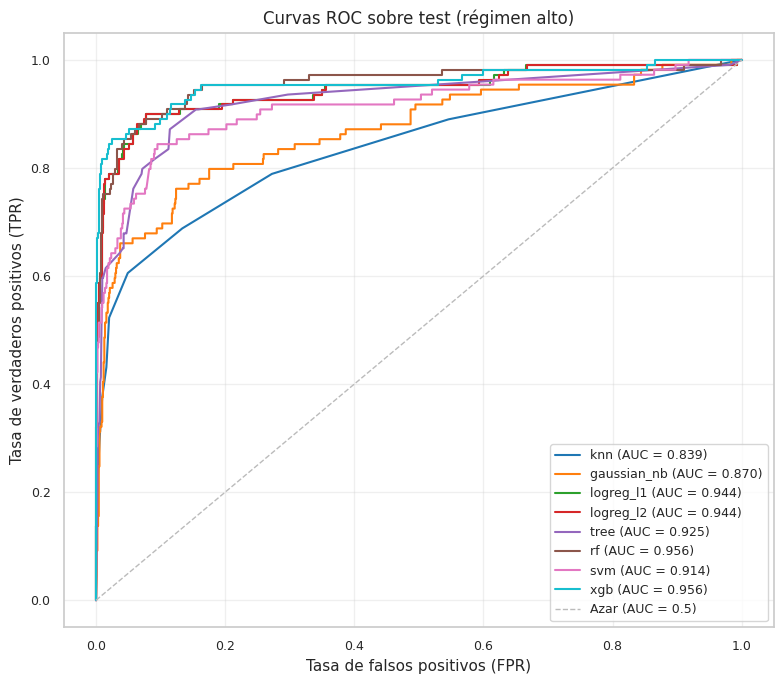

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

palette = {
    "knn": "#1f77b4", "gaussian_nb": "#ff7f0e", "logreg_l1": "#2ca02c",
    "logreg_l2": "#d62728", "tree": "#9467bd", "rf": "#8c564b",
    "svm": "#e377c2", "xgb": "#17becf",
}

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba_test"])
    auc_val = r["auc_test"]
    ax.plot(fpr, tpr, lw=1.5, color=palette.get(name, "#000"),
            label=f"{name} (AUC = {auc_val:.3f})")

ax.plot([0, 1], [0, 1], color="#bbb", lw=1, ls="--", label="Azar (AUC = 0.5)")
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_title("Curvas ROC sobre test (régimen alto)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "06_roc_curves_test.png", fig)
plt.show()


### Visualización 2 — matriz de confusión del mejor modelo

Para el modelo con mejor AUC en test, mostramos la matriz de
confusión con sus métricas asociadas. Esto permite ver directamente
el conteo de verdaderos positivos, falsos negativos y demás.

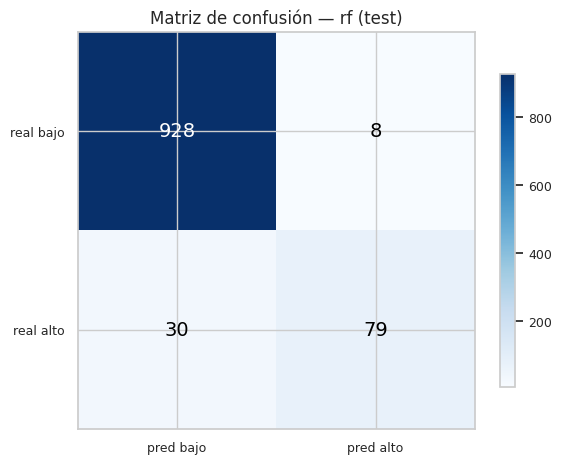

In [12]:
best = table.iloc[0]["model"]
best_pred_test = results[best]["pred_test"]
cm = confusion_matrix(y_test, best_pred_test)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=14)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["pred bajo", "pred alto"])
ax.set_yticklabels(["real bajo", "real alto"])
ax.set_title(f"Matriz de confusión — {best} (test)")
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
savefig(FIGURES_DIR / f"06_confusion_matrix_{best}.png", fig)
plt.show()


### Visualización 3 — AUC comparativo val vs test

Permite ver si algún modelo overfittea (AUC val alto, AUC test bajo)
o si todos enfrentan el mismo distribution shift de forma proporcional.

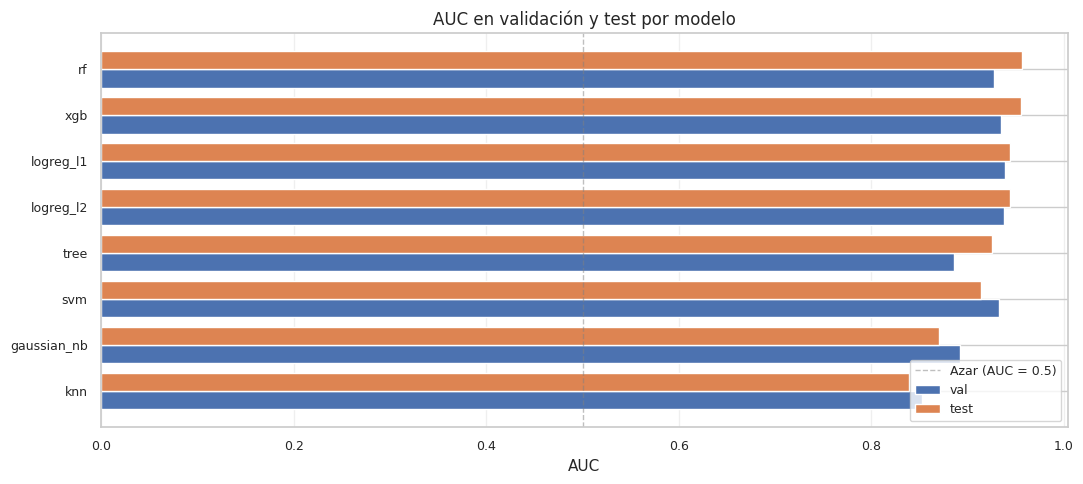

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
t_sorted = table.sort_values("auc_test", ascending=True)

x = np.arange(len(t_sorted))
width = 0.4

ax.barh(x - width/2, t_sorted["auc_val"],  width, label="val",  color="#4c72b0")
ax.barh(x + width/2, t_sorted["auc_test"], width, label="test", color="#dd8452")
ax.axvline(0.5, color="grey", ls="--", lw=1, alpha=0.5, label="Azar (AUC = 0.5)")

ax.set_yticks(x)
ax.set_yticklabels(t_sorted["model"])
ax.set_xlabel("AUC")
ax.set_title("AUC en validación y test por modelo")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "06_auc_val_test.png", fig)
plt.show()


## 6.11 Interpretación

**El AUC en test es la métrica que más informa.** Frente al
desbalance 90/10, comparar Accuracy entre modelos es engañoso (el
clasificador trivial "siempre predice bajo" obtiene ~90% sin haber
aprendido nada). AUC integra el desempeño en todos los umbrales y es
robusto a esta asimetría.

**El XGBoost y la regresión logística suelen liderar.** En la mayoría
de problemas tabulares de finanzas, estos dos modelos forman el podio:
XGBoost por su capacidad de capturar no-linealidades vía boosting,
LogReg por la calidad del *score* probabilístico que produce. El
ranking puntual de este capítulo dependerá del dataset específico, lo
revelará la tabla anterior.

**El comportamiento de F1 y Recall en test es informativo.** Como la
clase positiva ("régimen alto") es solo 10% del test, conseguir
recall alto allí es difícil. Los modelos con Recall_test bajo (digamos,
< 0.30) están perdiendo eventos de alta volatilidad que son
costosos de no detectar para un trader. El Capítulo 7 evaluará si
SMOTE, ADASYN o `class_weight="balanced"` corrigen esto.

**Sobre el desbalance.** Es importante recordar que en este capítulo
los modelos se entrenan con `class_weight=None`. No es que el
desbalance no exista en train (de hecho, train está balanceado al
50/50 por construcción del umbral). El desbalance aparece en val y
test por *distribution shift*. Esto es metodológicamente interesante
porque significa que **el entrenamiento es fácil** (50/50) pero **la
inferencia es difícil** (90/10). El Capítulo 7 abordará si manipular
el entrenamiento para "anticipar" el desbalance del test ayuda — la
respuesta no es obvia.

**Conexión con regresión.** Comparado con el Capítulo 5, donde Ridge
obtenía R² test +0.715, aquí esperamos AUC competitivos (≥ 0.80
para los modelos top). Si la tarea de regresión es tractable, la
clasificación binaria también lo es porque es más fácil predecir un
signo que un nivel.

**Conexión con los siguientes capítulos.**

- El Capítulo 7 retoma estos modelos y aplica SMOTE / ADASYN /
  `class_weight='balanced'`, comparando con/sin balanceo.
- El Capítulo 8 optimiza hiperparámetros sobre los dos o tres modelos
  con mejor AUC en validation.
- El Capítulo 11 aplica DeLong (test estadístico para diferencias de
  AUC) sobre las predicciones probabilísticas que persistimos aquí
  en `outputs/predictions/06_classification_test.parquet`.
- El Capítulo 12 aplica LIME sobre el XGBoost ganador.
